In [3]:
import requests
import pandas as pd
import time

API_KEY = '97OGHWS77V9ZH0G7' 

# Individual ETF symbols related to EV production metals
etf_LIT = 'LIT'
etf_COPX = 'COPX'
etf_DBB = 'DBB'
etf_PICK = 'PICK'
etf_REMX = 'REMX'
etf_JJN = 'JJN'

# Helper function to fetch ETF daily data
def fetch_daily_data(symbol, api_key):
    url = 'https://www.alphavantage.co/query'
    params = {
        'function': 'TIME_SERIES_DAILY',
        'symbol': symbol,
        'outputsize': 'full',
        'apikey': api_key
    }

    print(f"Fetching data for {symbol}...")
    response = requests.get(url, params=params)
    
    if response.status_code != 200:
        print(f"HTTP Error {response.status_code}")
        return None

    data = response.json()

    if 'Time Series (Daily)' not in data:
        print(f"API issue for {symbol}: {data.get('Note') or data.get('Error Message') or 'Unknown error'}")
        return None

    df = pd.DataFrame.from_dict(data['Time Series (Daily)'], orient='index')
    df.index = pd.to_datetime(df.index)
    df = df.rename(columns={
        '1. open': 'open',
        '2. high': 'high',
        '3. low': 'low',
        '4. close': 'close',
        '5. volume': 'volume'
    })
    df = df[['open', 'high', 'low', 'close', 'volume']].astype(float)
    df = df.sort_index()
    return df

In [4]:
# Fetch and store each ETF with individual variable names
df_LIT = fetch_daily_data(etf_LIT, API_KEY)
time.sleep(12)

df_COPX = fetch_daily_data(etf_COPX, API_KEY)
time.sleep(12)

df_REMX = fetch_daily_data(etf_REMX, API_KEY)
time.sleep(12)

df_JJN = fetch_daily_data(etf_JJN, API_KEY)
time.sleep(12)

df_DBB = fetch_daily_data(etf_DBB, API_KEY)
time.sleep(12)

df_PICK = fetch_daily_data(etf_PICK, API_KEY)
time.sleep(12)

# Add ETF name as prefix to columns
def label_columns(df, label):
    df = df.copy()
    df.columns = [f"{label}_{col.lower()}" for col in df.columns]
    return df

df_LIT_labeled = label_columns(df_LIT, "LIT")
df_COPX_labeled = label_columns(df_COPX, "COPX")
df_DBB_labeled = label_columns(df_DBB, "DBB")
df_PICK_labeled = label_columns(df_PICK, "PICK")
df_REMX_labeled = label_columns(df_REMX, 'REMX')
df_JJN_labeled = label_columns(df_JJN, 'NICKL')

# Merge all on index (date)
merged_etfs = df_LIT_labeled.join([
    df_COPX_labeled,
    df_DBB_labeled,
    df_PICK_labeled,
    df_JJN_labeled,
    df_REMX_labeled
], how='outer')

# Optional: sort index
merged_etfs = merged_etfs.sort_index()
merged_etfs.dropna(inplace=True)

Fetching data for LIT...
API issue for LIT: Unknown error
Fetching data for COPX...
API issue for COPX: Unknown error


KeyboardInterrupt: 

In [1]:
merged_etfs.head()
merged_etfs.to_csv("full_metal_etfs.csv")

NameError: name 'merged_etfs' is not defined

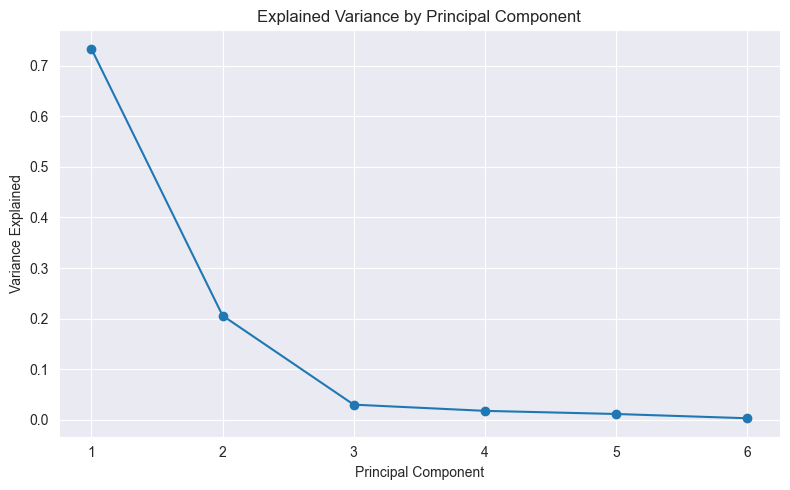


🔍 Explained Variance Ratio:
PC1: 0.7337
PC2: 0.2058
PC3: 0.0295
PC4: 0.0173
PC5: 0.0111
PC6: 0.0026

📈 PCA Component Loadings:
          LIT      COPX       JJN       JJC       DBB      PICK
PC1  0.444569  0.443431 -0.344462 -0.322628  0.439061  0.436131
PC2  0.048483  0.300091  0.585094  0.630029  0.237530  0.334518
PC3 -0.808952 -0.000998 -0.002451 -0.206956  0.533892  0.133107
PC4  0.209901 -0.040848  0.722550 -0.616634  0.129091 -0.187865
PC5 -0.308615  0.482801  0.111020 -0.263442 -0.664398  0.385367
PC6  0.079388 -0.691771  0.067833 -0.080652 -0.087607  0.704534


In [17]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load your ETF CSVs
df_LIT = pd.read_csv('LIT_daily.csv', index_col=0, parse_dates=True)
df_COPX = pd.read_csv('COPX_daily.csv', index_col=0, parse_dates=True)
df_JJN = pd.read_csv('JJN_daily.csv', index_col=0, parse_dates=True)
df_JJC = pd.read_csv('JJC_daily.csv', index_col=0, parse_dates=True)
df_DBB = pd.read_csv('DBB_daily.csv', index_col=0, parse_dates=True)
df_PICK = pd.read_csv('PICK_daily.csv', index_col=0, parse_dates=True)

# Create a single DataFrame of just 'close' prices
close_prices = pd.DataFrame({
    'LIT': df_LIT['close'],
    'COPX': df_COPX['close'],
    'JJN': df_JJN['close'],
    'JJC': df_JJC['close'],
    'DBB': df_DBB['close'],
    'PICK': df_PICK['close'],
})

# Drop missing values
close_prices.dropna(inplace=True)

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(close_prices)

# Run PCA
pca = PCA(n_components=len(close_prices.columns))
X_pca = pca.fit_transform(X_scaled)

# Create a scree plot (variance explained)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_, marker='o')
plt.title('Explained Variance by Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.grid(True)
plt.tight_layout()
plt.show()

# Print explained variance ratio
print("\n🔍 Explained Variance Ratio:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f}")

# Show PCA component loadings
components_df = pd.DataFrame(
    pca.components_,
    columns=close_prices.columns,
    index=[f'PC{i+1}' for i in range(len(close_prices.columns))]
)

print("\nPCA Component Loadings:")
print(components_df)

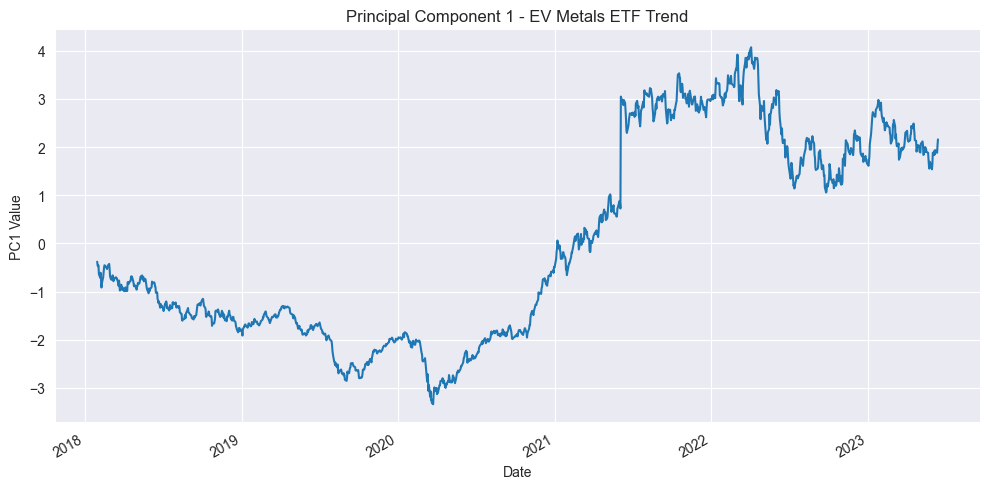

In [18]:
import matplotlib.pyplot as plt

# Plot PC1 over timei was 
pc1_series = pd.Series(X_pca[:, 0], index=close_prices.index)

plt.figure(figsize=(10, 5))
pc1_series.plot()
plt.title('Principal Component 1 - EV Metals ETF Trend')
plt.xlabel('Date')
plt.ylabel('PC1 Value')
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
close_prices.head()

,LIT,COPX,JJN,JJC,DBB,PICK
2018-01-29,38.27,28.70,55.75,50.22,19.58,37.53
2018-01-30,37.67,28.26,55.75,50.22,19.52,36.94
2018-01-31,37.54,28.07,55.75,50.22,19.55,36.75
2018-02-01,36.89,28.21,56.40,50.22,19.72,37.00
2018-02-02,35.45,27.19,54.48,50.22,19.49,35.01
